# EMD-Based Time Series Forecasting

> **Reference paper**: Awajan, A. M., Ismail, M. T. & AL Wadi, S. (2019). *A review on empirical mode decomposition in forecasting time series*. Italian Journal of Pure and Applied Mathematics, 42, 301–323.

That paper is a **survey** of hybrid EMD forecasting methods (EMD–ARIMA, EMD–SVR/LSSVR, EMD–ANN, …). Across those studies the same three-stage pipeline appears:

1. **Decompose** a nonlinear / non-stationary series with EMD into IMFs + residue  
2. **Forecast each component** with a classical predictor (AR / SVR / neural net, …)  
3. **Aggregate** component forecasts by summation to recover the series forecast  

This notebook reproduces that hybrid framework with PySDKit’s `EMD`, compares it against forecasting the raw series directly, and provides a full visualization workflow.

> **Important**: to avoid look-ahead leakage we run EMD **only on the training window**, then produce recursive multi-step forecasts for the test horizon.


## 1. Hybrid EMD forecasting framework (paper §2.4)

Paper quote (paraphrased):

> Use EMD to decompose non-stationary and nonlinear time series into IMFs and a residual. Forecast each component. Aggregate the forecasts to obtain the final prediction of the original series.

$$
x(t)=\sum_{i=1}^{n}\mathrm{IMF}_i(t)+r(t)
\quad\Rightarrow\quad
\hat x(t+h)=\sum_{i=1}^{n}\widehat{\mathrm{IMF}}_i(t+h)+\hat r(t+h).
$$

| Hybrid (as surveyed) | Component model |
|----------------------|-----------------|
| EMD–ARIMA / EMD–AR | linear autoregression |
| EMD–SVR / EMD–LSSVR | support-vector regression |
| EMD–ANN / EMD–BPN | neural network |

We implement **EMD–AR**, **EMD–SVR**, and **EMD–MLP**, plus the same models **without** EMD as baselines.


## 2. Imports and helper functions

~~~bash
pip install scikit-learn
~~~

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from pysdkit import EMD
from pysdkit.plot import plot_IMFs

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

RNG = np.random.default_rng(42)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def make_lagged(y, lags):
    y = np.asarray(y, dtype=float)
    X, t = [], []
    for i in range(lags, len(y)):
        X.append(y[i - lags : i])
        t.append(y[i])
    return np.asarray(X), np.asarray(t)


def build_model(kind='ar', lags=10, random_state=0):
    if kind == 'ar':
        # Ridge AR: stable linear autoregression (ARIMA-like AR core)
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    if kind == 'svr':
        return make_pipeline(
            StandardScaler(),
            SVR(kernel='rbf', C=10.0, epsilon=0.05, gamma='scale'),
        )
    if kind == 'mlp':
        return make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation='relu',
                max_iter=500,
                random_state=random_state,
                early_stopping=True,
                validation_fraction=0.15,
            ),
        )
    raise ValueError(kind)


def recursive_forecast(series, horizon, lags=10, kind='ar', random_state=0):
    # Fit on `series`, then produce `horizon` recursive one-step predictions.
    series = np.asarray(series, dtype=float)
    if len(series) <= lags + 2:
        # too short: persist last value
        return np.full(horizon, series[-1] if len(series) else 0.0)
    X, y = make_lagged(series, lags)
    model = build_model(kind, lags, random_state)
    model.fit(X, y)
    hist = list(series[-lags:])
    preds = []
    for _ in range(horizon):
        x = np.asarray(hist[-lags:], dtype=float).reshape(1, -1)
        p = float(model.predict(x)[0])
        preds.append(p)
        hist.append(p)
    return np.asarray(preds)


@dataclass
class ForecastResult:
    yhat: np.ndarray
    component_forecasts: np.ndarray  # (n_comp, horizon)
    imfs: np.ndarray
    residue: np.ndarray


def emd_hybrid_forecast(
    train,
    horizon,
    lags=10,
    kind='ar',
    max_imfs=6,
    random_state=0,
):
    # Paper §2.4 pipeline on the training window only.
    emd = EMD(max_imfs=max_imfs)
    imfs = emd.fit_transform(train)
    imfs_arr, residue = emd.get_imfs_and_residue()
    comps = list(imfs_arr) + [residue]
    comp_forecasts = []
    for c in comps:
        comp_forecasts.append(
            recursive_forecast(c, horizon, lags=lags, kind=kind, random_state=random_state)
        )
    comp_forecasts = np.asarray(comp_forecasts)
    yhat = comp_forecasts.sum(axis=0)
    return ForecastResult(
        yhat=yhat,
        component_forecasts=comp_forecasts,
        imfs=imfs_arr,
        residue=residue,
    )

## 3. Synthetic nonlinear / non-stationary series

Following the survey’s application domains (wind, load, finance, …), we build a series with **trend + slow seasonality + fast oscillation + amplitude modulation + noise** — hard for a single linear model, natural for EMD hybrids.


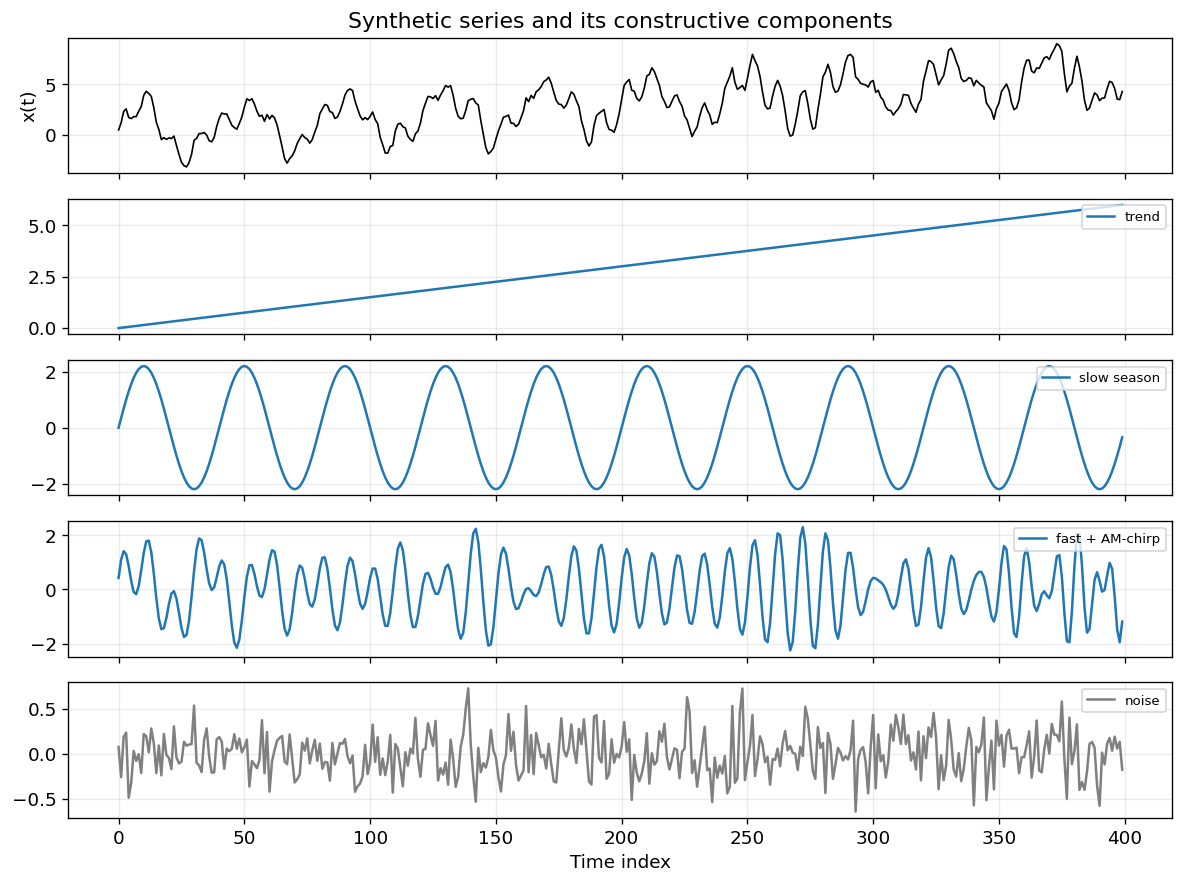

In [2]:
n = 400
t = np.arange(n)
trend = 0.015 * t
season_slow = 2.2 * np.sin(2 * np.pi * t / 40.0)
season_fast = 1.1 * np.sin(2 * np.pi * t / 10.0 + 0.4)
am_chirp = (0.8 + 0.4 * np.sin(2 * np.pi * t / 120.0)) * np.sin(
    2 * np.pi * (0.03 * t + 0.00015 * t**2)
)
noise = 0.25 * RNG.normal(size=n)
series = trend + season_slow + season_fast + am_chirp + noise

fig, axs = plt.subplots(5, 1, figsize=(10, 7.5), sharex=True)
axs[0].plot(t, series, 'k', lw=1.0)
axs[0].set_ylabel('x(t)')
axs[0].set_title('Synthetic series and its constructive components')
axs[1].plot(t, trend, label='trend')
axs[2].plot(t, season_slow, label='slow season')
axs[3].plot(t, season_fast + am_chirp, label='fast + AM-chirp')
axs[4].plot(t, noise, label='noise', color='0.5')
for ax in axs[1:]:
    ax.legend(fontsize=8, loc='upper right')
axs[-1].set_xlabel('Time index')
plt.tight_layout()
plt.show()

## 4. Train / test split

We hold out the last $H$ points as the forecast horizon. EMD and model fitting use **only** the training segment.


Train length=352, test horizon H=48, lags=12


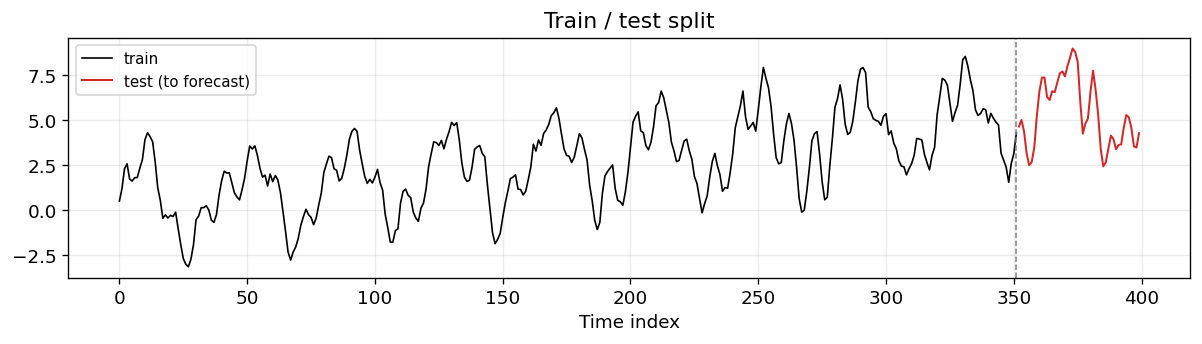

In [ ]:
HORIZON = 48
LAGS = 12
MAX_IMFS = 5

train = series[:-HORIZON]
test = series[-HORIZON:]
t_train = t[:-HORIZON]
t_test = t[-HORIZON:]
print(f'Train length={len(train)}, test horizon H={HORIZON}, lags={LAGS}')

fig, ax = plt.subplots(figsize=(10, 3.0))
ax.plot(t_train, train, 'k', lw=1.0, label='train')
ax.plot(t_test, test, 'C3', lw=1.2, label='test (to forecast)')
ax.axvline(t_train[-1], color='0.5', ls='--', lw=0.9)
ax.legend(fontsize=9)
ax.set_title('Train / test split')
ax.set_xlabel('Time index')
plt.tight_layout()
plt.show()

## 5. Step A — EMD on the training window

Visualize IMFs / residue extracted from training data only (paper §2 / completeness identity).


IMFs shape: (4, 352) | residue energy fraction: 0.6624
Reconstruction error on train: 2.576e-15


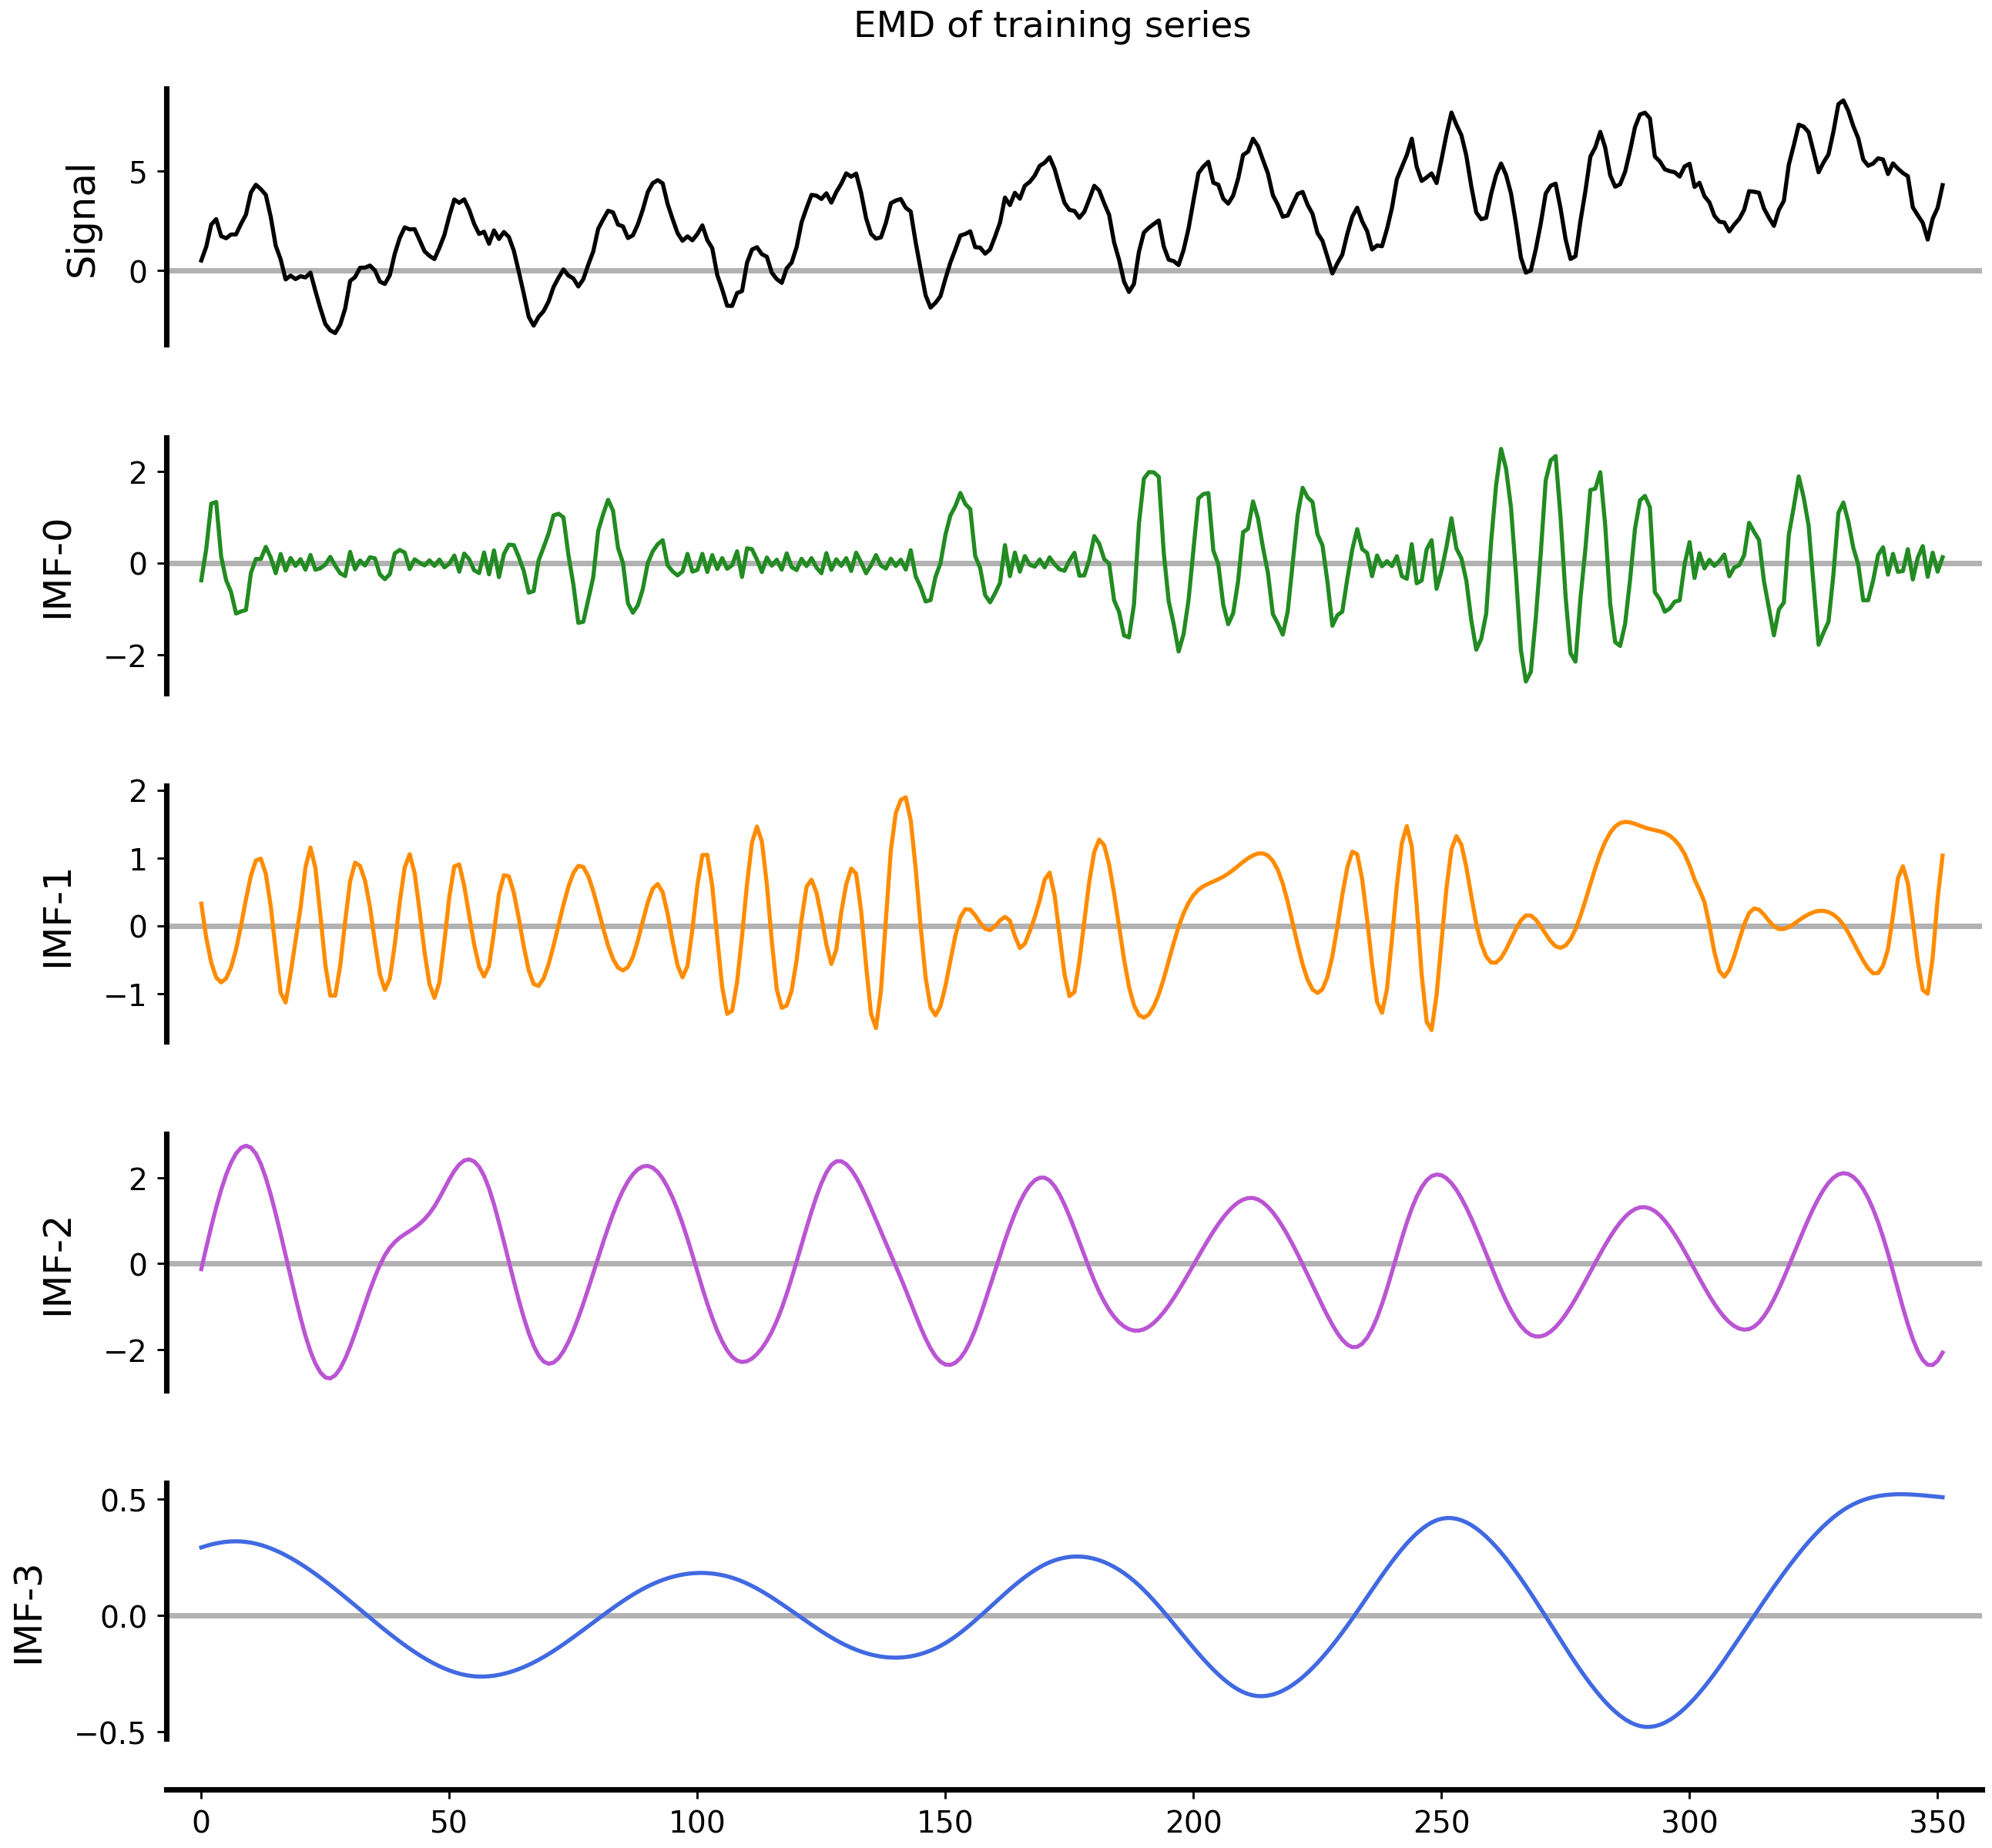

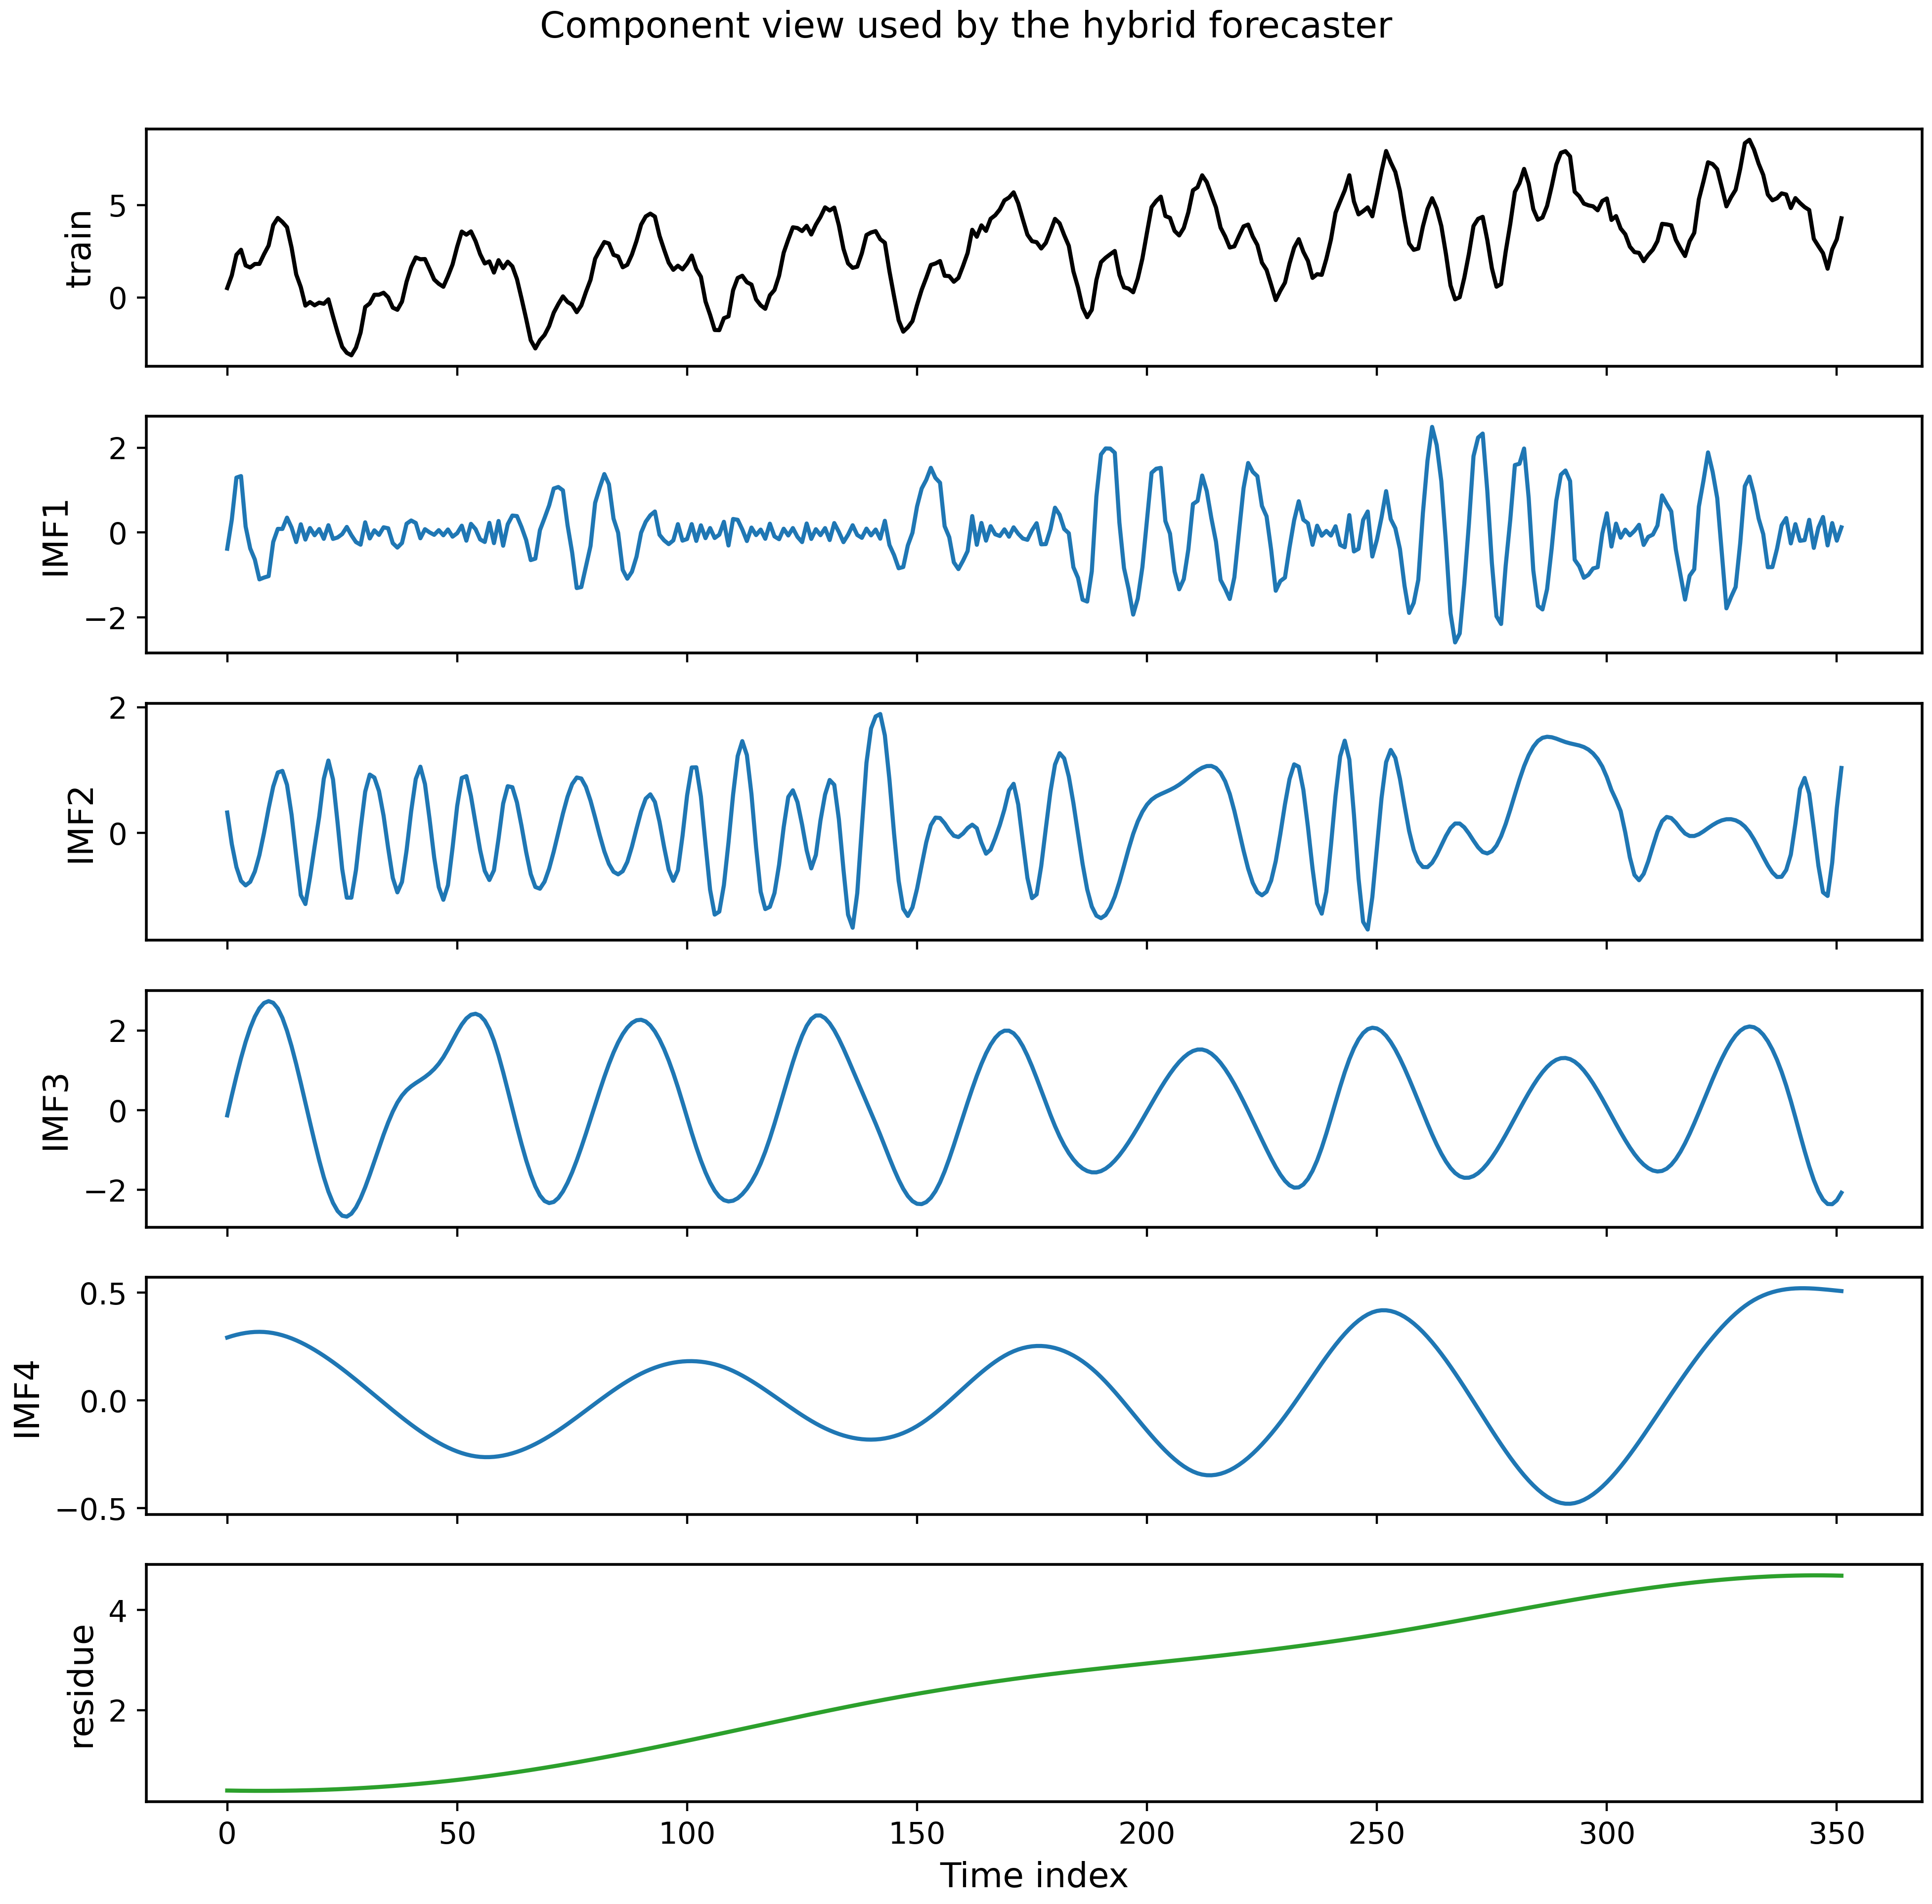

In [4]:
emd = EMD(max_imfs=MAX_IMFS)
imfs_train = emd.fit_transform(train)
imfs_arr, residue = emd.get_imfs_and_residue()
print('IMFs shape:', imfs_arr.shape, '| residue energy fraction:',
      f'{np.sum(residue**2) / np.sum(train**2):.4f}')
print('Reconstruction error on train:',
      f'{np.linalg.norm(train - (imfs_arr.sum(0) + residue)):.3e}')

fig = plot_IMFs(train, imfs_arr, return_figure=True)
plt.suptitle('EMD of training series', y=1.02)
plt.show()

fig, axs = plt.subplots(imfs_arr.shape[0] + 2, 1, figsize=(10, 1.6 * (imfs_arr.shape[0] + 2)), sharex=True)
axs[0].plot(t_train, train, 'k')
axs[0].set_ylabel('train')
for i in range(imfs_arr.shape[0]):
    axs[i + 1].plot(t_train, imfs_arr[i])
    axs[i + 1].set_ylabel(f'IMF{i+1}')
axs[-1].plot(t_train, residue, color='C2')
axs[-1].set_ylabel('residue')
axs[-1].set_xlabel('Time index')
plt.suptitle('Component view used by the hybrid forecaster', y=1.01)
plt.tight_layout()
plt.show()


## 6. Step B — Forecast each component, then aggregate

For every IMF and the residue we fit a lag-$p$ predictor and generate $H$ recursive forecasts. The hybrid forecast is their sum (paper §2.4).


EMD-AR RMSE: 1.3679


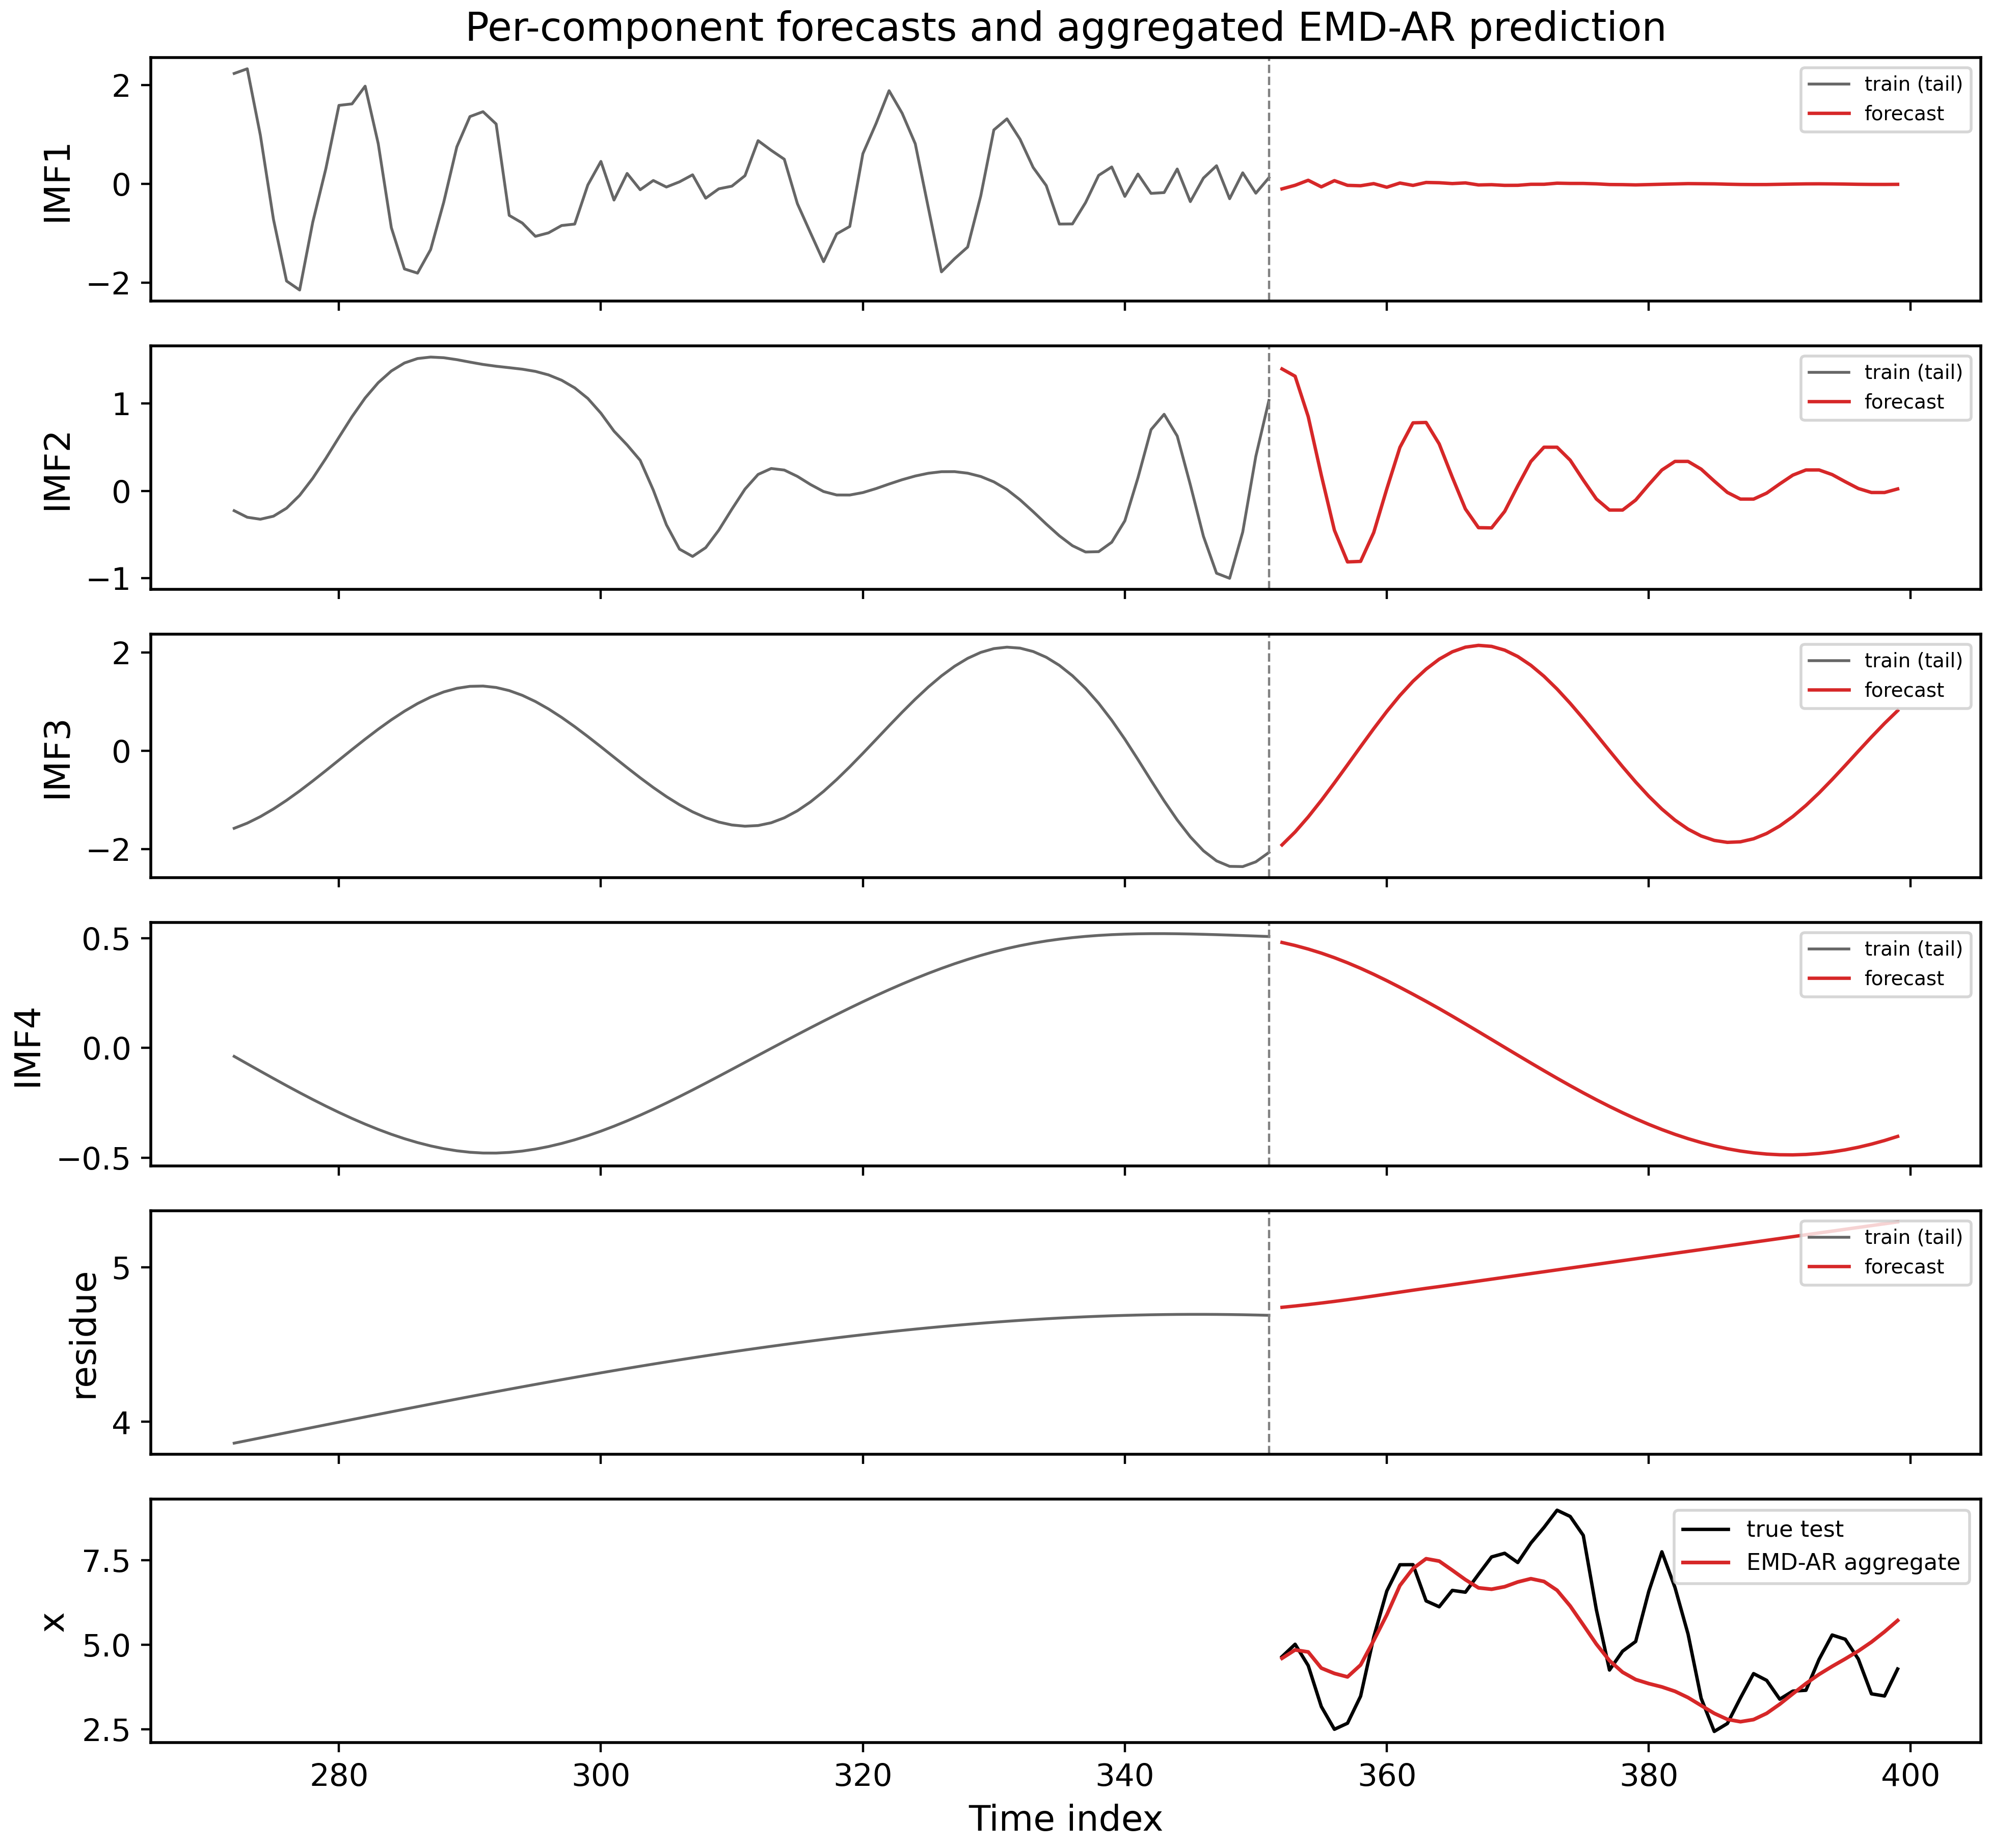

In [5]:
result_ar = emd_hybrid_forecast(train, HORIZON, lags=LAGS, kind='ar', max_imfs=MAX_IMFS)
print('EMD-AR RMSE:', f"{rmse(test, result_ar.yhat):.4f}")

n_comp = result_ar.component_forecasts.shape[0]
fig, axs = plt.subplots(n_comp + 1, 1, figsize=(10, 1.55 * (n_comp + 1)), sharex=True)
# show last part of each training component + forecast
comps_train = list(result_ar.imfs) + [result_ar.residue]
labels = [f'IMF{i+1}' for i in range(result_ar.imfs.shape[0])] + ['residue']
for i in range(n_comp):
    axs[i].plot(t_train[-80:], comps_train[i][-80:], color='0.4', lw=1.0, label='train (tail)')
    axs[i].plot(t_test, result_ar.component_forecasts[i], 'C3', lw=1.2, label='forecast')
    axs[i].axvline(t_train[-1], color='0.5', ls='--', lw=0.8)
    axs[i].set_ylabel(labels[i])
    axs[i].legend(fontsize=7, loc='upper right')
axs[-1].plot(t_test, test, 'k', lw=1.2, label='true test')
axs[-1].plot(t_test, result_ar.yhat, 'C3', lw=1.3, label='EMD-AR aggregate')
axs[-1].legend(fontsize=8)
axs[-1].set_ylabel('x')
axs[-1].set_xlabel('Time index')
axs[0].set_title('Per-component forecasts and aggregated EMD-AR prediction')
plt.tight_layout()
plt.show()

## 7. Step C — Compare hybrid models vs direct baselines

We evaluate:

- **Direct-AR / Direct-SVR / Direct-MLP**: forecast the raw series  
- **EMD-AR / EMD-SVR / EMD-MLP**: paper-style hybrid aggregation  


Method                 RMSE        MAE      MAPE%
--------------------------------------------------
Direct-AR            3.2860     2.7053      44.63
EMD-AR               1.3679     1.0452      20.07
Direct-SVR           3.6538     2.9555      53.62
EMD-SVR              1.1809     1.0299      20.98
Direct-MLP           5.9777     5.5166     102.38
EMD-MLP              4.5332     2.3969      52.86


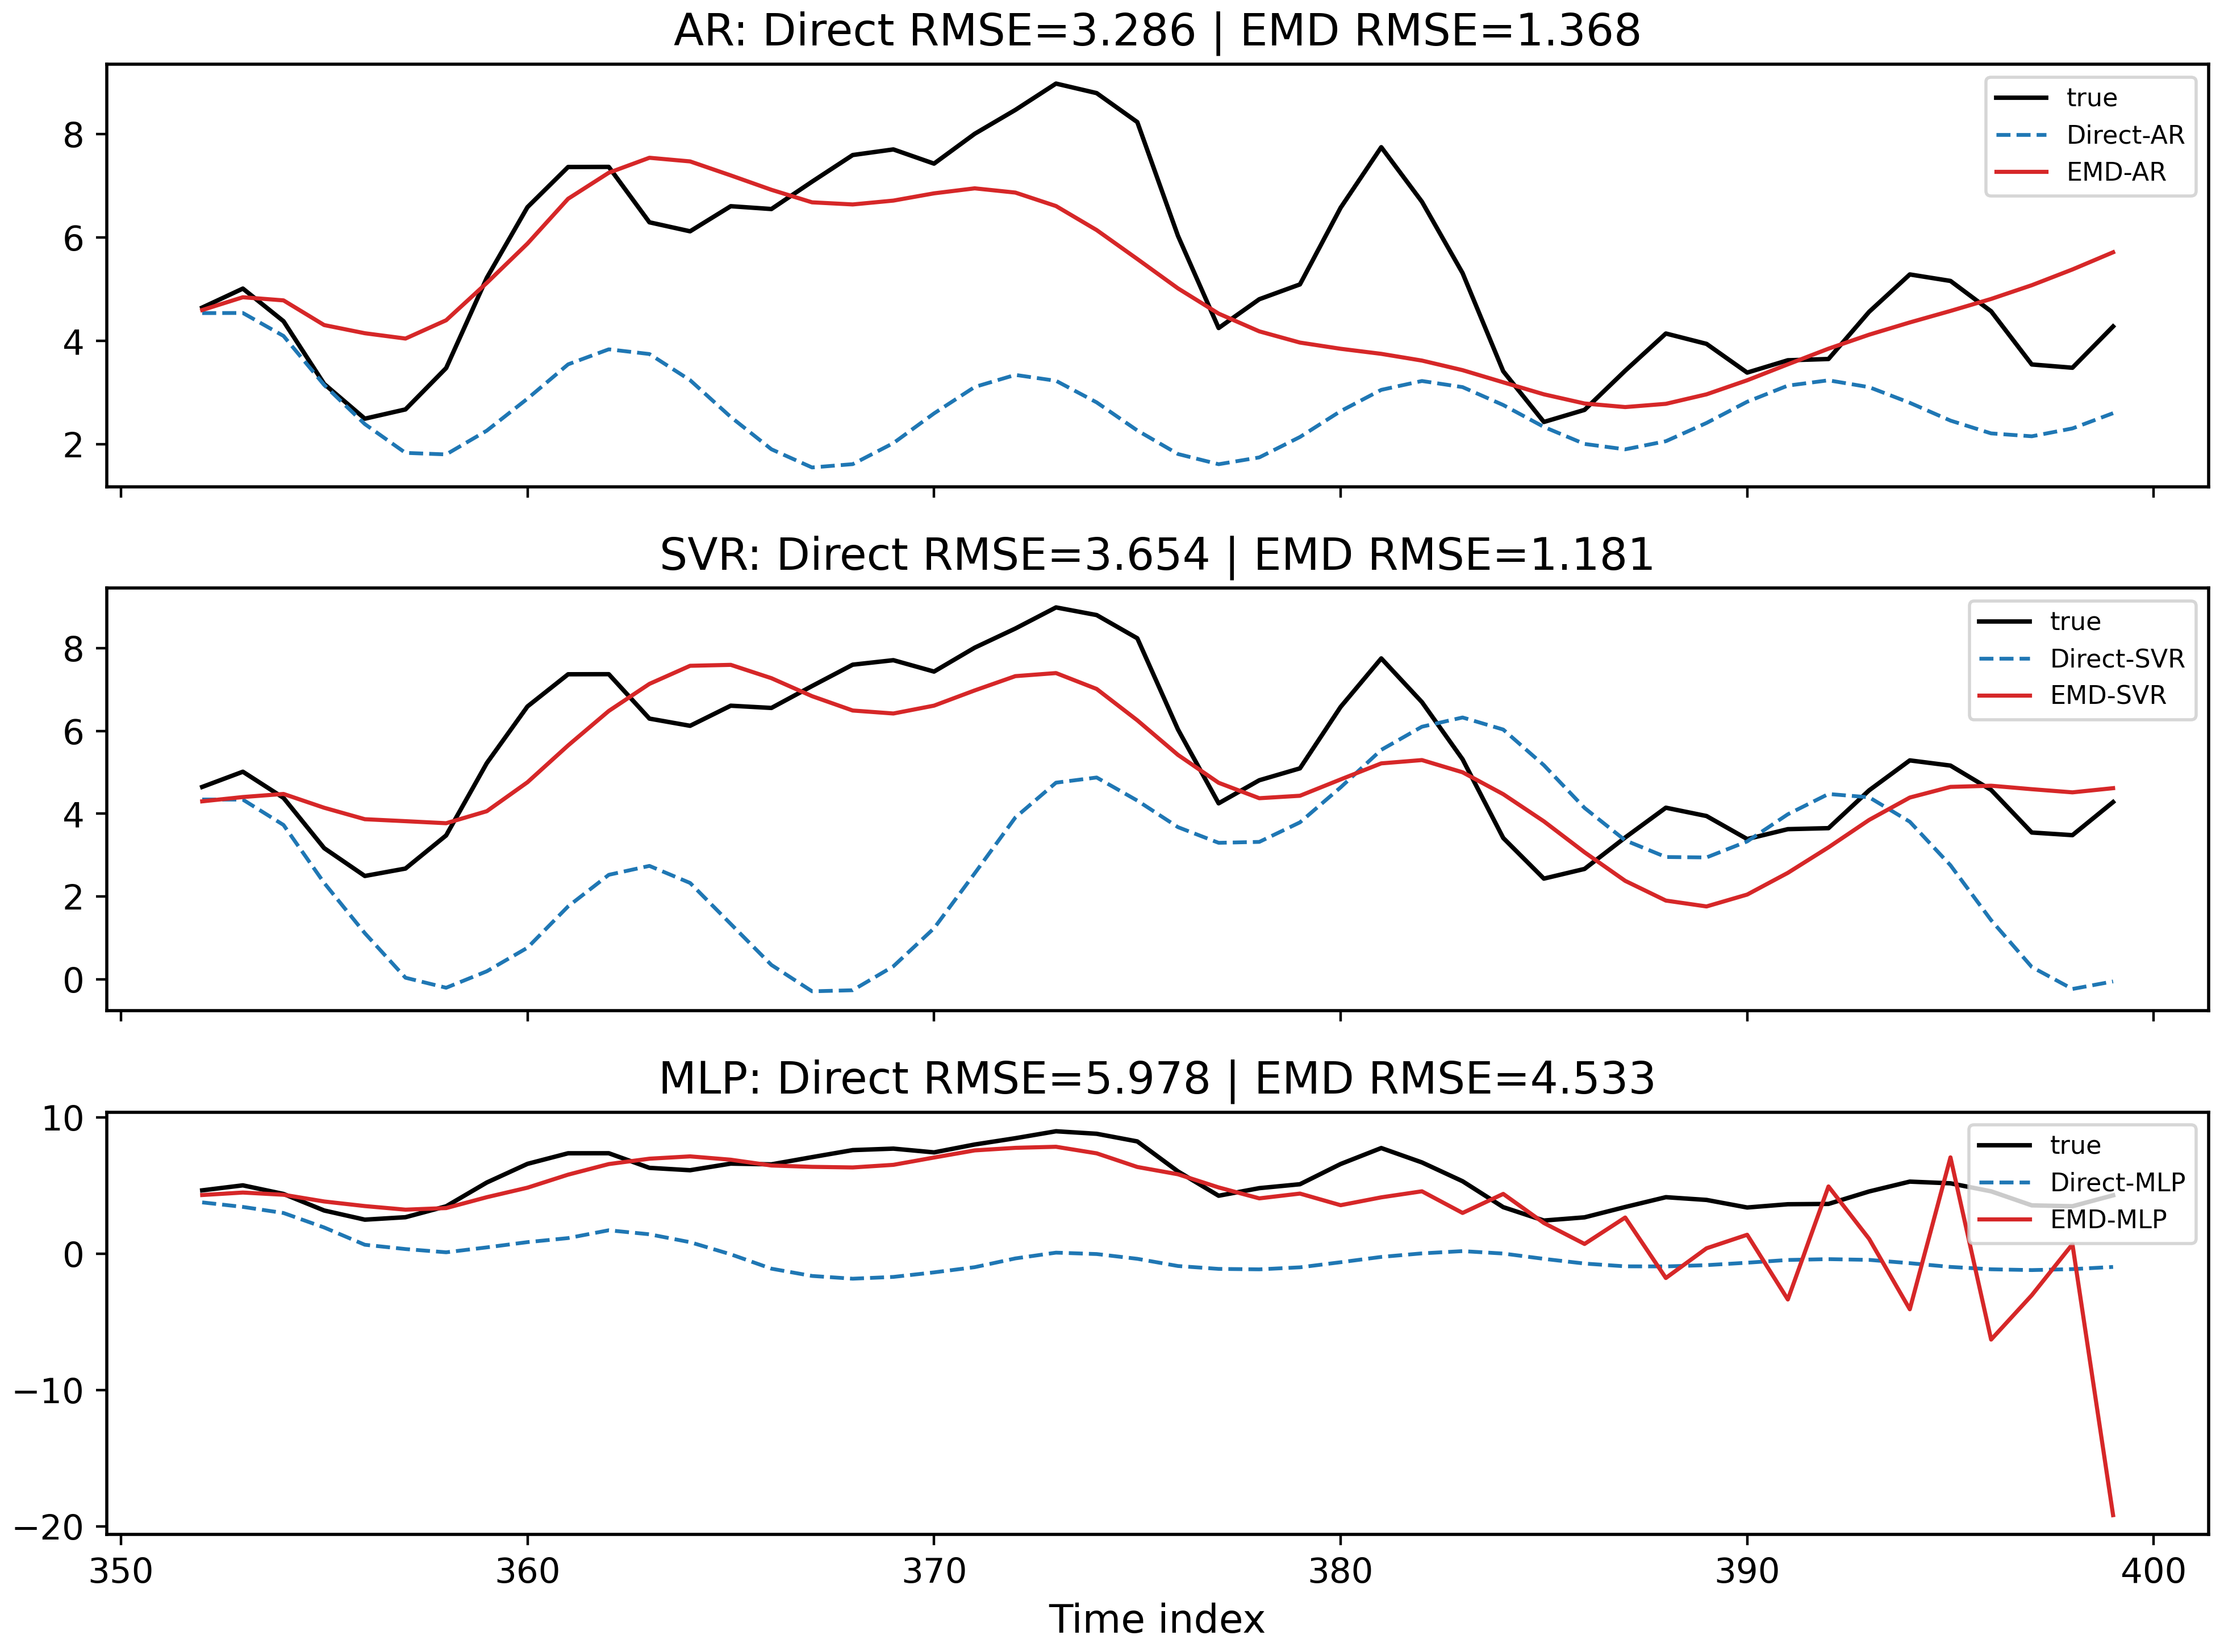

In [6]:
methods = {}

for kind in ['ar', 'svr', 'mlp']:
    # direct baseline
    yhat_dir = recursive_forecast(train, HORIZON, lags=LAGS, kind=kind, random_state=0)
    methods[f'Direct-{kind.upper()}'] = yhat_dir
    # EMD hybrid
    yhat_emd = emd_hybrid_forecast(
        train, HORIZON, lags=LAGS, kind=kind, max_imfs=MAX_IMFS, random_state=0
    ).yhat
    methods[f'EMD-{kind.upper()}'] = yhat_emd

rows = []
print(f"{'Method':16s} {'RMSE':>10s} {'MAE':>10s} {'MAPE%':>10s}")
print('-' * 50)
for name, yhat in methods.items():
    r = rmse(test, yhat)
    a = mae(test, yhat)
    m = mape(test, yhat)
    rows.append((name, r, a, m, yhat))
    print(f'{name:16s} {r:10.4f} {a:10.4f} {m:10.2f}')

fig, axs = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
pairs = [('AR', 'ar'), ('SVR', 'svr'), ('MLP', 'mlp')]
for ax, (title, kind) in zip(axs, pairs):
    ax.plot(t_test, test, 'k', lw=1.4, label='true')
    ax.plot(t_test, methods[f'Direct-{kind.upper()}'], 'C0--', lw=1.2, label=f'Direct-{kind.upper()}')
    ax.plot(t_test, methods[f'EMD-{kind.upper()}'], 'C3', lw=1.3, label=f'EMD-{kind.upper()}')
    ax.set_title(
        f"{title}: Direct RMSE={rmse(test, methods[f'Direct-{kind.upper()}']):.3f} | "
        f"EMD RMSE={rmse(test, methods[f'EMD-{kind.upper()}']):.3f}"
    )
    ax.legend(fontsize=8, loc='upper right')
axs[-1].set_xlabel('Time index')
plt.tight_layout()
plt.show()

## 8. Error visualization and metric bars


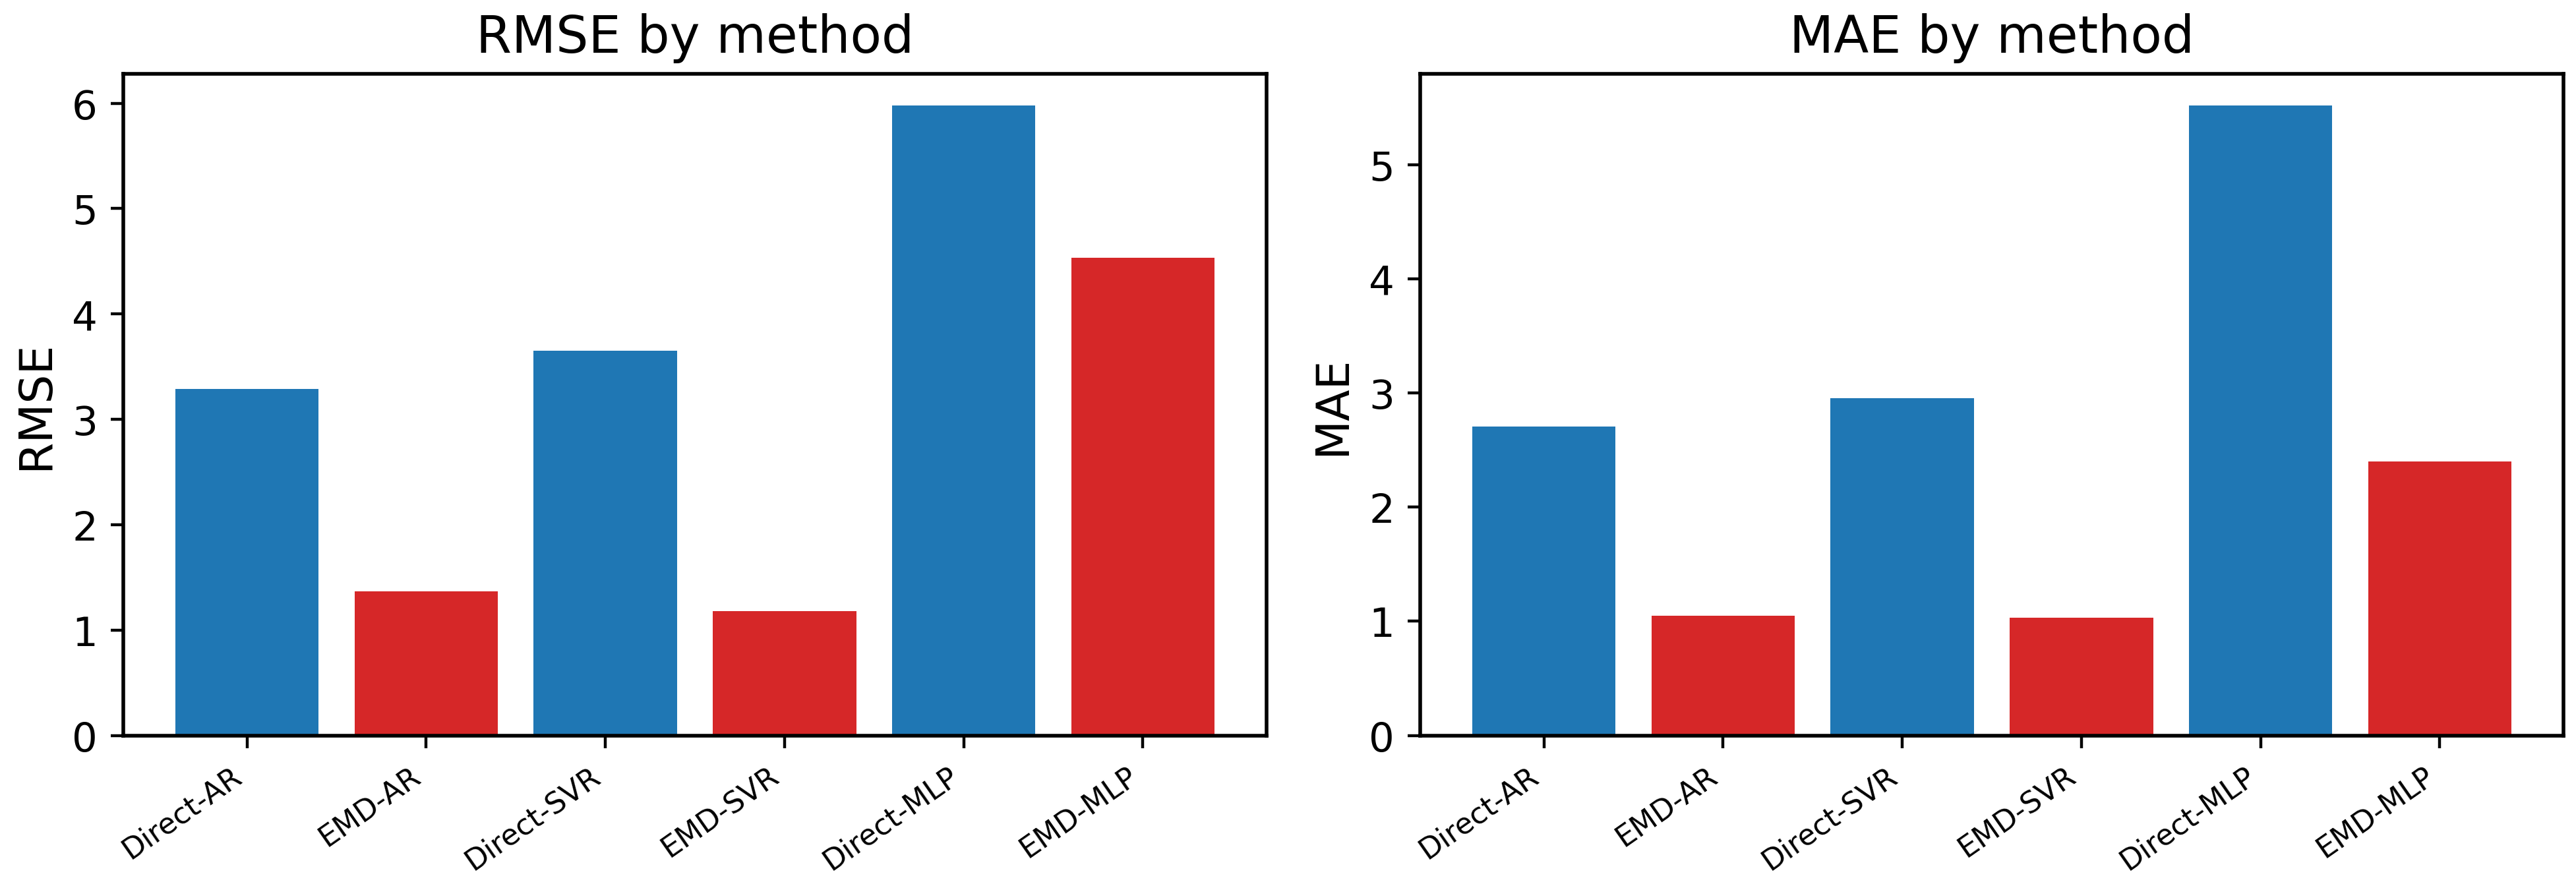

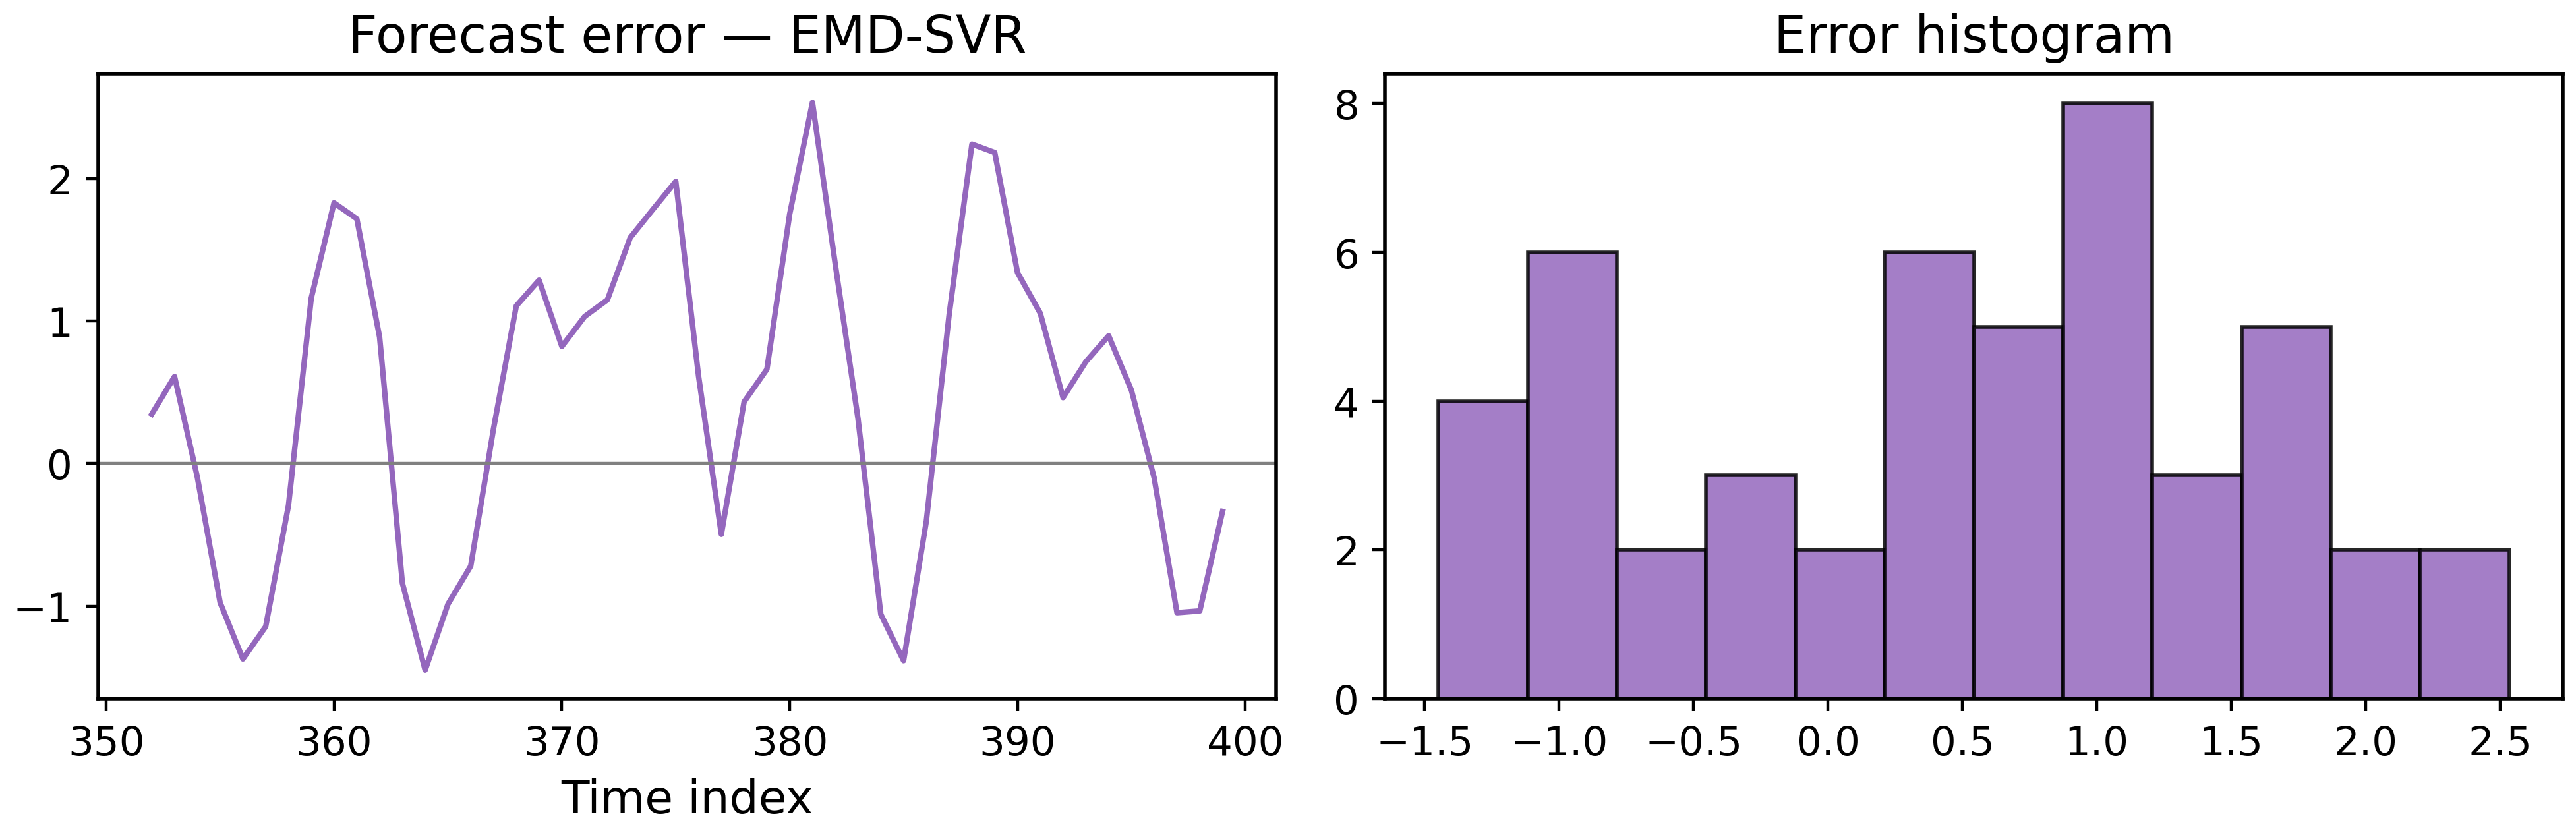

In [7]:
names = [r[0] for r in rows]
rmses = [r[1] for r in rows]
maes = [r[2] for r in rows]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
xpos = np.arange(len(names))
axs[0].bar(xpos, rmses, color=['C0' if n.startswith('Direct') else 'C3' for n in names])
axs[0].set_xticks(xpos)
axs[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axs[0].set_ylabel('RMSE')
axs[0].set_title('RMSE by method')
axs[1].bar(xpos, maes, color=['C0' if n.startswith('Direct') else 'C3' for n in names])
axs[1].set_xticks(xpos)
axs[1].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axs[1].set_ylabel('MAE')
axs[1].set_title('MAE by method')
plt.tight_layout()
plt.show()

# Residual diagnostics for best EMD method
emd_rows = [r for r in rows if r[0].startswith('EMD')]
best = min(emd_rows, key=lambda r: r[1])
best_name, best_yhat = best[0], best[4]
err = test - best_yhat
fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
axs[0].plot(t_test, err, color='C4')
axs[0].axhline(0, color='0.5', lw=0.8)
axs[0].set_title(f'Forecast error — {best_name}')
axs[0].set_xlabel('Time index')
axs[1].hist(err, bins=12, color='C4', edgecolor='k', alpha=0.85)
axs[1].set_title('Error histogram')
plt.tight_layout()
plt.show()

## 9. Rolling one-step evaluation (optional, closer to online use)

Multi-step recursion accumulates error. A stricter protocol repeatedly expands the training window by one observation, re-runs EMD, and forecasts only the next step. We use a shorter rolling segment for runtime.


Rolling one-step Direct-AR RMSE: 0.8847
Rolling one-step EMD-AR    RMSE: 0.9293


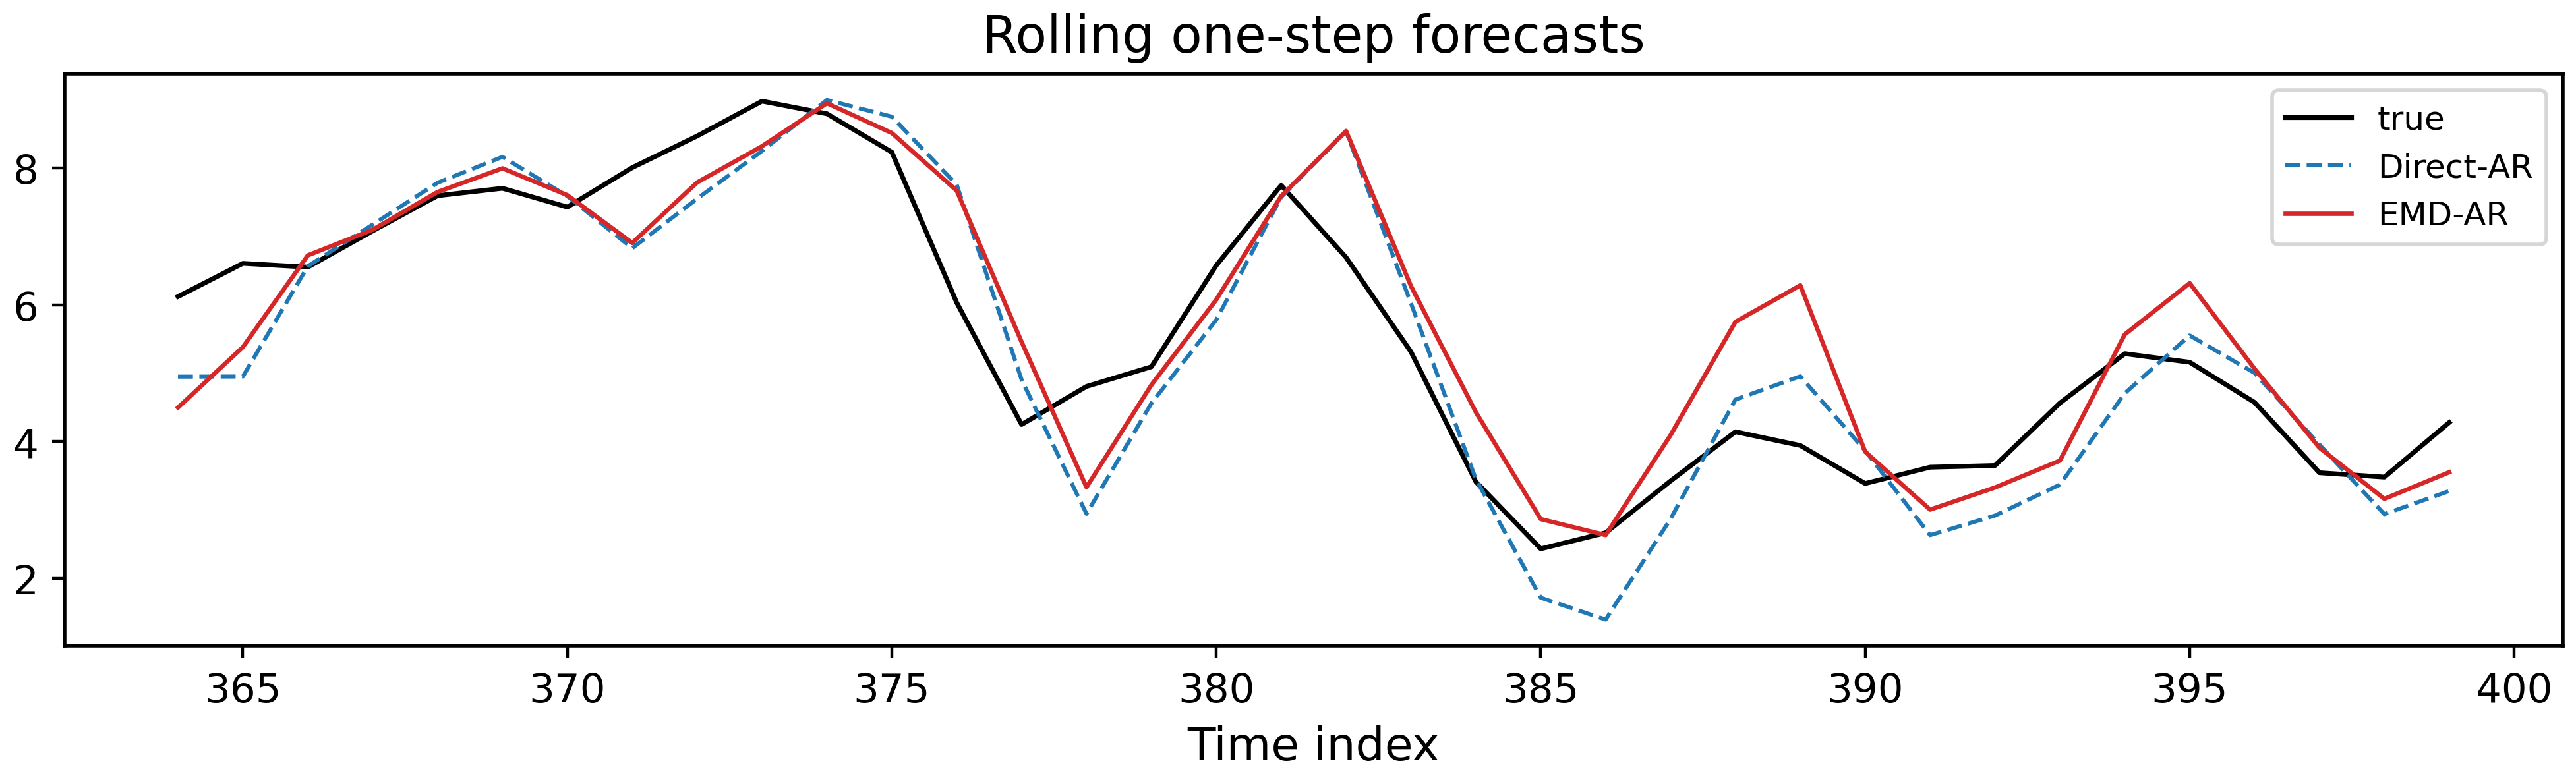

In [8]:
ROLL_START = len(series) - 36  # last 36 points as rolling origin
roll_true = []
roll_emd = []
roll_dir = []

for i in range(ROLL_START, len(series)):
    tr = series[:i]
    # one-step forecasts
    roll_dir.append(recursive_forecast(tr, horizon=1, lags=LAGS, kind='ar')[0])
    roll_emd.append(
        emd_hybrid_forecast(tr, horizon=1, lags=LAGS, kind='ar', max_imfs=MAX_IMFS).yhat[0]
    )
    roll_true.append(series[i])

roll_true = np.asarray(roll_true)
roll_emd = np.asarray(roll_emd)
roll_dir = np.asarray(roll_dir)
print('Rolling one-step Direct-AR RMSE:', f'{rmse(roll_true, roll_dir):.4f}')
print('Rolling one-step EMD-AR    RMSE:', f'{rmse(roll_true, roll_emd):.4f}')

tt = t[ROLL_START:]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(tt, roll_true, 'k', lw=1.3, label='true')
ax.plot(tt, roll_dir, 'C0--', lw=1.1, label='Direct-AR')
ax.plot(tt, roll_emd, 'C3', lw=1.2, label='EMD-AR')
ax.legend(fontsize=9)
ax.set_title('Rolling one-step forecasts')
ax.set_xlabel('Time index')
plt.tight_layout()
plt.show()

## 10. Summary

**Algorithm reproduced from the review (Awajan et al., 2019, §2.4)**

```text
Input: training series x_train, horizon H, predictor M
1. [IMF_1, ..., IMF_n, r] <- EMD(x_train)
2. for each component c in {IMF_1,...,IMF_n,r}:
       hat_c(1..H) <- recursive forecast of c with model M
3. hat_x(1..H) <- sum_c hat_c
```

**Visualization workflow in this notebook**

1. Series construction / exploratory plot  
2. Train–test split  
3. EMD components on the training window  
4. Per-component forecasts  
5. Aggregation vs ground truth  
6. Hybrid vs direct baselines (AR / SVR / MLP)  
7. Error bars / residual diagnostics  
8. Optional rolling one-step protocol  

**Practical remarks from the survey**

- EMD helps when the series mixes multiple time scales.  
- Component models can be heterogeneous (e.g. AR on highly autocorrelated IMFs, SVR on weakly correlated ones — see EMD–LSSVM–AR variants in the review).  
- Always avoid decomposing the future test segment before forecasting.  
- For noisy series, consider EEMD/CEEMDAN (also discussed in the review) before forecasting.

### Minimal usage pattern

```python
from pysdkit import EMD
# see emd_hybrid_forecast(...) defined above
out = emd_hybrid_forecast(train, horizon=48, lags=12, kind='svr')
y_hat = out.yhat
```

### Related notebooks

- `examples/emd.ipynb` — sifting pipeline  
- `examples/emd_denoising.ipynb` — EMD preprocessing before modeling  
- `examples/hht.ipynb` — Hilbert spectrum of IMFs  
